# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/atharvasoundankar/fmcg-sales-marketing-and-profit-data/fmcg_sales_marketing_profitability_2023_2025.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/atharvasoundankar/fmcg-sales-marketing-and-profit-data/fmcg_sales_marketing_profitability_2023_2025.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,...,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,...,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84
1,FMCG-2024-000002,2024-10-09,2024,Q4,10,October,Asia,India,Mumbai,Meera Nair,...,99,2.89,9.86,286.11,35.26,123.79,23.89,257.90,74.96,29.07
2,FMCG-2024-000003,2024-07-06,2024,Q3,7,July,North America,USA,Los Angeles,Nina Booker,...,361,5.96,15.32,2151.56,171.46,1011.60,107.02,1821.94,531.86,29.19
3,FMCG-2024-000004,2024-05-25,2024,Q2,5,May,Europe,France,Paris,Oliver Kent,...,603,3.80,18.00,2291.40,118.39,1133.66,85.20,1878.95,541.70,28.83
4,FMCG-2023-000005,2023-08-10,2023,Q3,8,August,Europe,France,Lyon,Lucas Bennett,...,113,3.18,12.46,359.34,34.82,157.70,23.02,314.57,99.03,31.48


## last Five row

In [4]:
df.tail()

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,...,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
18235,FMCG-2023-018236,2023-01-19,2023,Q1,1,January,Asia,Indonesia,Jakarta,Anika Verma,...,39,7.87,13.68,306.93,41.32,149.17,31.24,264.94,43.21,16.31
18236,FMCG-2023-018237,2023-06-22,2023,Q2,6,June,Europe,Spain,Madrid,Elena Dupont,...,53,6.06,13.93,321.18,35.42,155.27,21.25,276.44,64.50,23.33
18237,FMCG-2025-018238,2025-10-30,2025,Q4,10,October,Europe,France,Paris,Marco Bellini,...,143,3.43,13.21,490.49,72.35,314.69,36.50,425.70,2.16,0.51
18238,FMCG-2023-018239,2023-12-25,2023,Q4,12,December,South America,Brazil,Rio de Janeiro,Lucia Herrera,...,237,6.02,13.82,1426.74,124.61,713.18,92.59,1229.56,299.18,24.33
18239,FMCG-2024-018240,2024-06-20,2024,Q2,6,June,Europe,Germany,Hamburg,Marco Bellini,...,83,3.42,6.07,283.86,43.66,184.79,32.67,266.63,5.51,2.07


## Shape of our dataset

In [5]:
df.shape

(18240, 27)

## List out all columns

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Year', 'Quarter', 'Month', 'Month_Name',
       'Region', 'Country', 'City', 'Sales_Person', 'Customer_Type',
       'Sales_Channel', 'Promotion_Type', 'Product_Category', 'Brand',
       'Product_Name', 'SKU', 'Units_Sold', 'Unit_Price_USD', 'Discount_Pct',
       'Gross_Sales_USD', 'Marketing_Spend_USD', 'COGS_USD',
       'Logistics_Cost_USD', 'Net_Revenue_USD', 'Profit_USD',
       'Profit_Margin_Pct'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Order_ID                object
Order_Date              object
Year                     int64
Quarter                 object
Month                    int64
Month_Name              object
Region                  object
Country                 object
City                    object
Sales_Person            object
Customer_Type           object
Sales_Channel           object
Promotion_Type          object
Product_Category        object
Brand                   object
Product_Name            object
SKU                     object
Units_Sold               int64
Unit_Price_USD         float64
Discount_Pct           float64
Gross_Sales_USD        float64
Marketing_Spend_USD    float64
COGS_USD               float64
Logistics_Cost_USD     float64
Net_Revenue_USD        float64
Profit_USD             float64
Profit_Margin_Pct      float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18240 entries, 0 to 18239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             18240 non-null  object 
 1   Order_Date           18240 non-null  object 
 2   Year                 18240 non-null  int64  
 3   Quarter              18240 non-null  object 
 4   Month                18240 non-null  int64  
 5   Month_Name           18240 non-null  object 
 6   Region               18240 non-null  object 
 7   Country              18240 non-null  object 
 8   City                 18240 non-null  object 
 9   Sales_Person         18240 non-null  object 
 10  Customer_Type        18240 non-null  object 
 11  Sales_Channel        18240 non-null  object 
 12  Promotion_Type       18240 non-null  object 
 13  Product_Category     18240 non-null  object 
 14  Brand                18240 non-null  object 
 15  Product_Name         18240 non-null 

## Check Null Value

In [9]:
df.isnull().sum()

Order_ID               0
Order_Date             0
Year                   0
Quarter                0
Month                  0
Month_Name             0
Region                 0
Country                0
City                   0
Sales_Person           0
Customer_Type          0
Sales_Channel          0
Promotion_Type         0
Product_Category       0
Brand                  0
Product_Name           0
SKU                    0
Units_Sold             0
Unit_Price_USD         0
Discount_Pct           0
Gross_Sales_USD        0
Marketing_Spend_USD    0
COGS_USD               0
Logistics_Cost_USD     0
Net_Revenue_USD        0
Profit_USD             0
Profit_Margin_Pct      0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Year,Month,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
count,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000
mean,2024.001590,6.519024,212.909759,4.467254,12.935771,936.431746,85.741888,471.024278,54.031789,792.210526,181.412572,19.870780
std,0.816752,3.467308,202.102318,1.949341,5.735972,1045.606955,87.551045,537.351019,51.266996,861.237271,239.526879,10.569275
min,2023.000000,1.000000,5.000000,1.450000,0.000000,13.020000,1.810000,6.310000,1.080000,10.540000,-637.500000,-45.310000
25%,2023.000000,3.000000,70.000000,3.020000,8.710000,274.532500,33.495000,140.510000,21.370000,245.217500,32.345000,13.720000
50%,2024.000000,7.000000,139.000000,3.990000,12.690000,565.430000,61.385000,287.165000,38.985000,493.895000,91.890000,20.870000
75%,2025.000000,10.000000,288.000000,5.440000,16.850000,1213.835000,107.605000,599.790000,69.240000,1027.362500,239.117500,27.260000
max,2025.000000,12.000000,1366.000000,12.740000,28.000000,10634.120000,1767.710000,6473.330000,628.860000,8752.940000,2723.000000,44.490000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

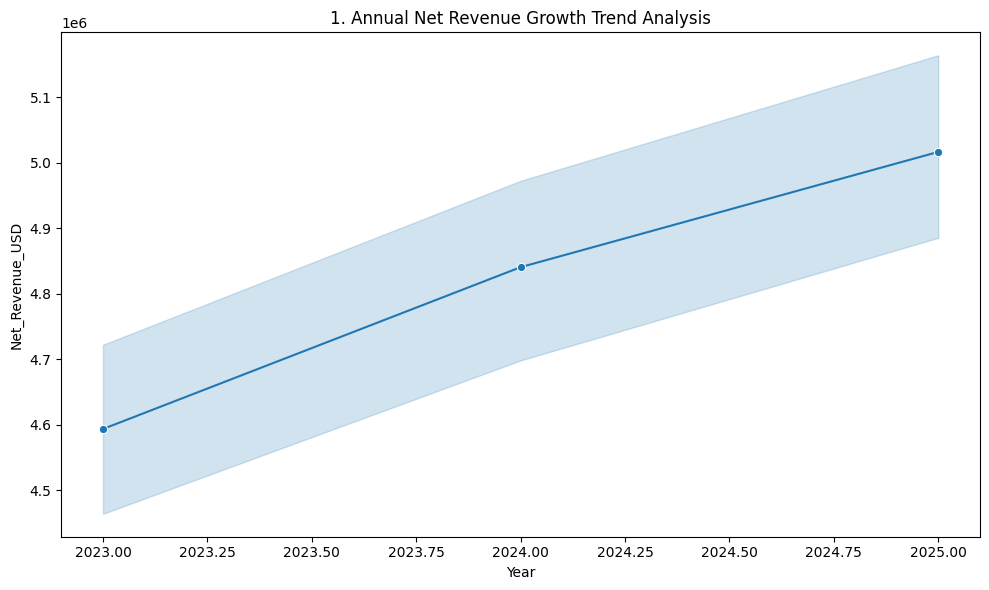

In [13]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='Net_Revenue_USD', estimator='sum', marker='o')
plt.title(f'{plot_no}. Annual Net Revenue Growth Trend Analysis')
show_fig()
plot_no += 1

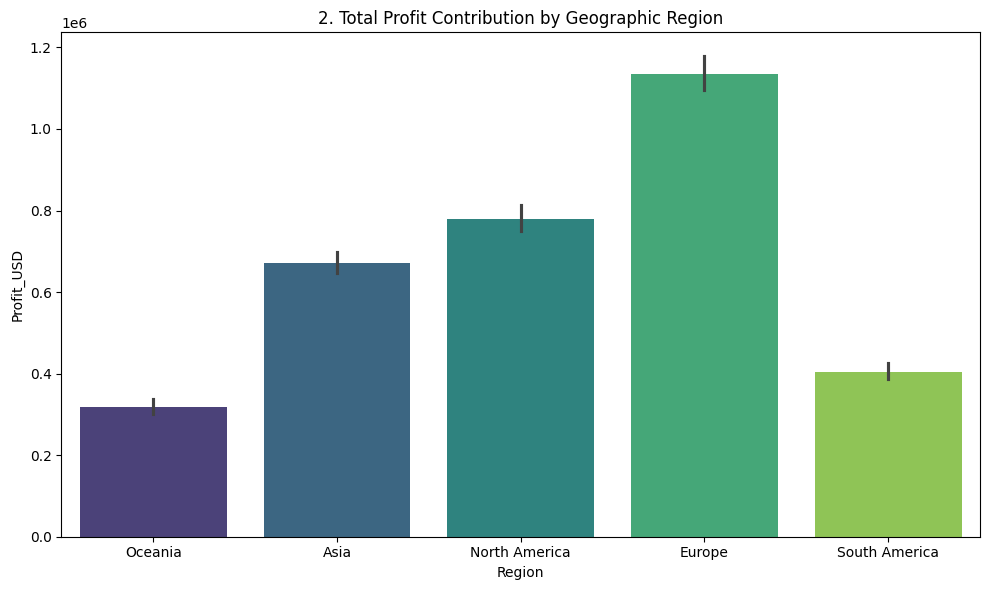

In [14]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Region', y='Profit_USD', estimator='sum', palette='viridis')
plt.title(f'{plot_no}. Total Profit Contribution by Geographic Region')
show_fig()
plot_no += 1

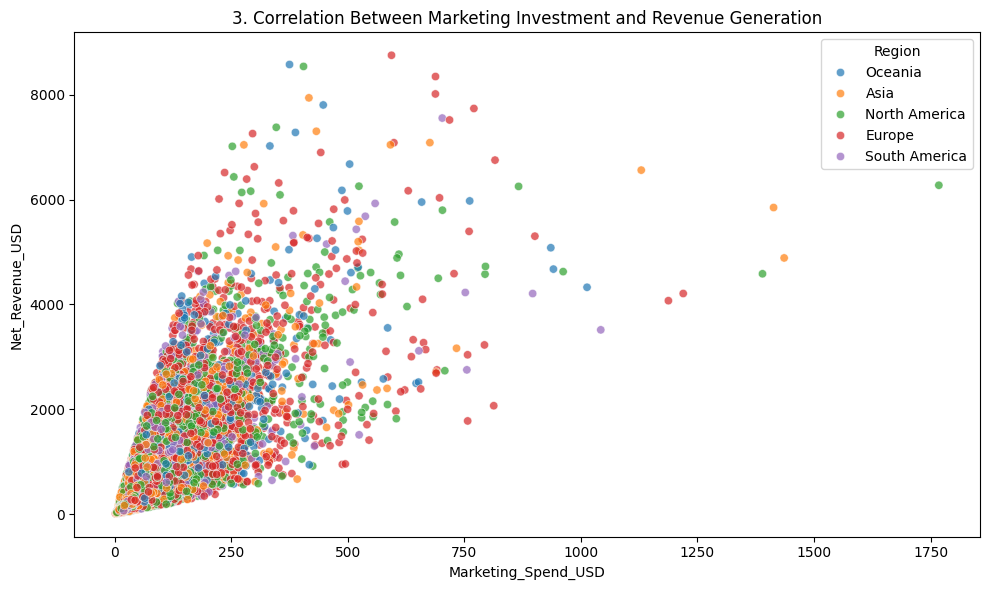

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Marketing_Spend_USD', y='Net_Revenue_USD', hue='Region', alpha=0.7)
plt.title(f'{plot_no}. Correlation Between Marketing Investment and Revenue Generation')
show_fig()
plot_no += 1

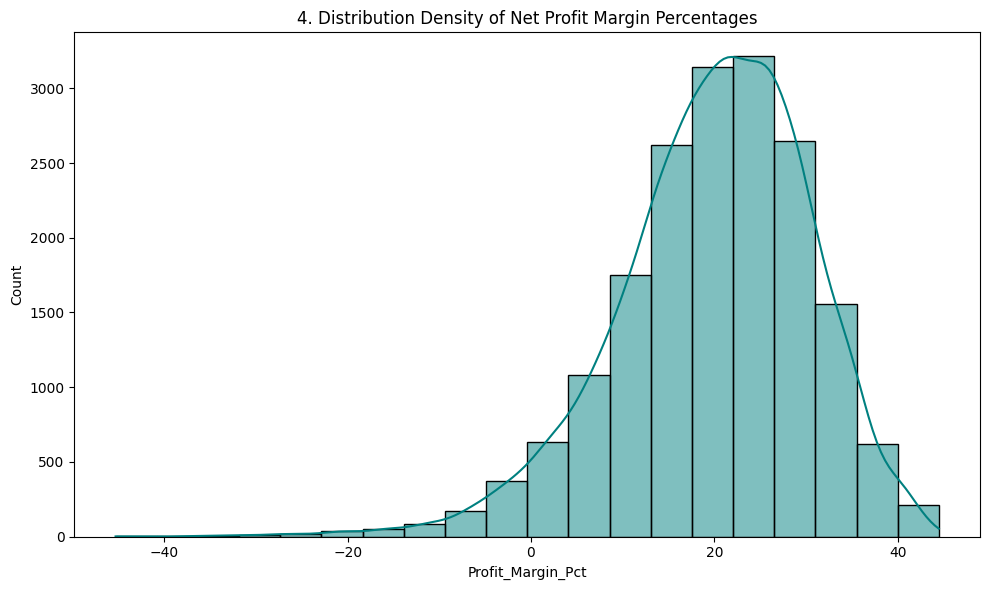

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Profit_Margin_Pct'], bins=20, kde=True, color='teal')
plt.title(f'{plot_no}. Distribution Density of Net Profit Margin Percentages')
show_fig()
plot_no += 1

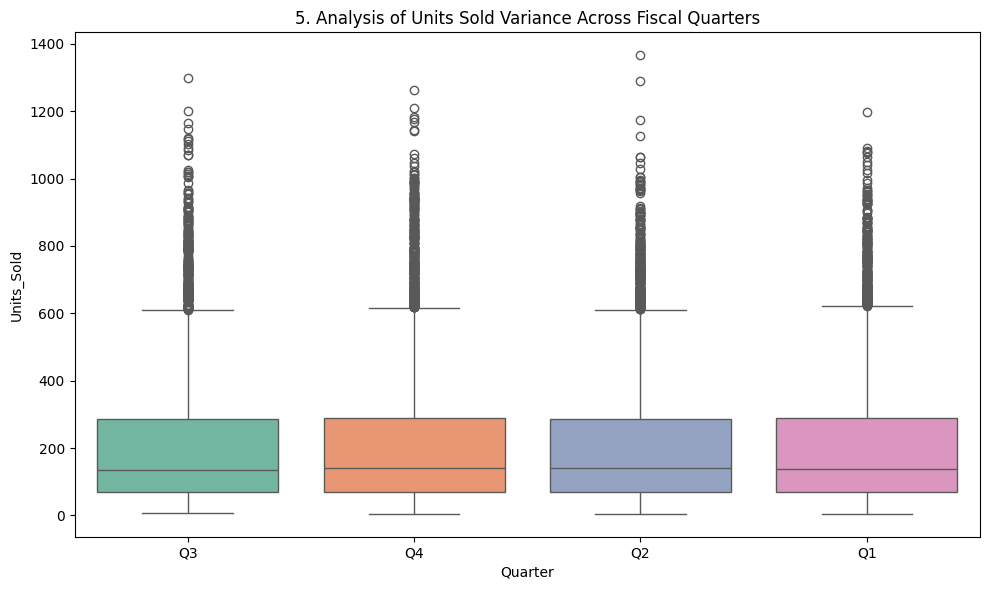

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Quarter', y='Units_Sold', palette='Set2')
plt.title(f'{plot_no}. Analysis of Units Sold Variance Across Fiscal Quarters')
show_fig()
plot_no += 1

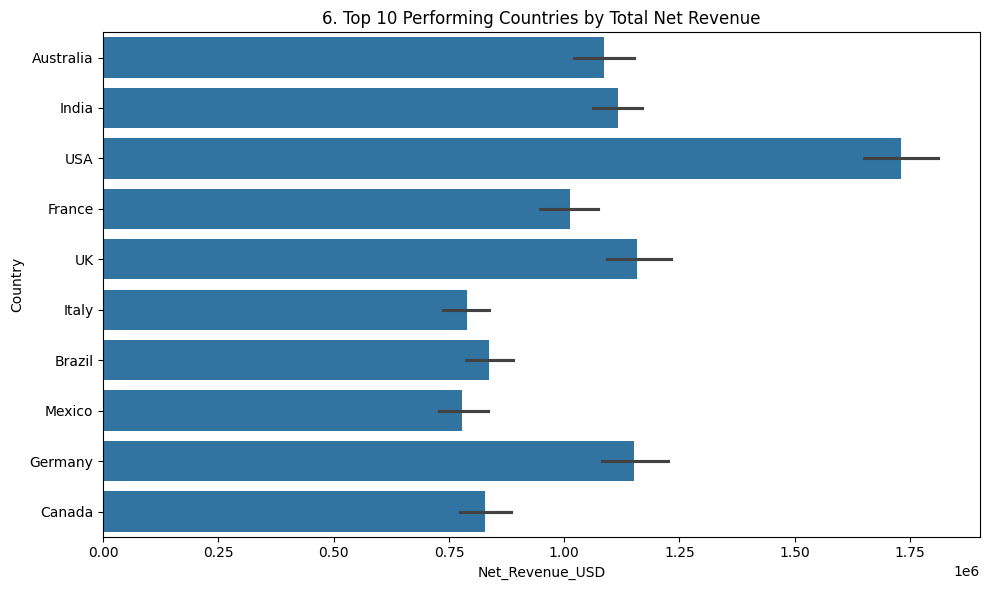

In [18]:
fig = plt.figure(figsize=(10,6))
top_countries = df.groupby('Country')['Net_Revenue_USD'].sum().nlargest(10).index
sns.barplot(data=df[df['Country'].isin(top_countries)], x='Net_Revenue_USD', y='Country', estimator='sum', orient='h')
plt.title(f'{plot_no}. Top 10 Performing Countries by Total Net Revenue')
show_fig()
plot_no += 1

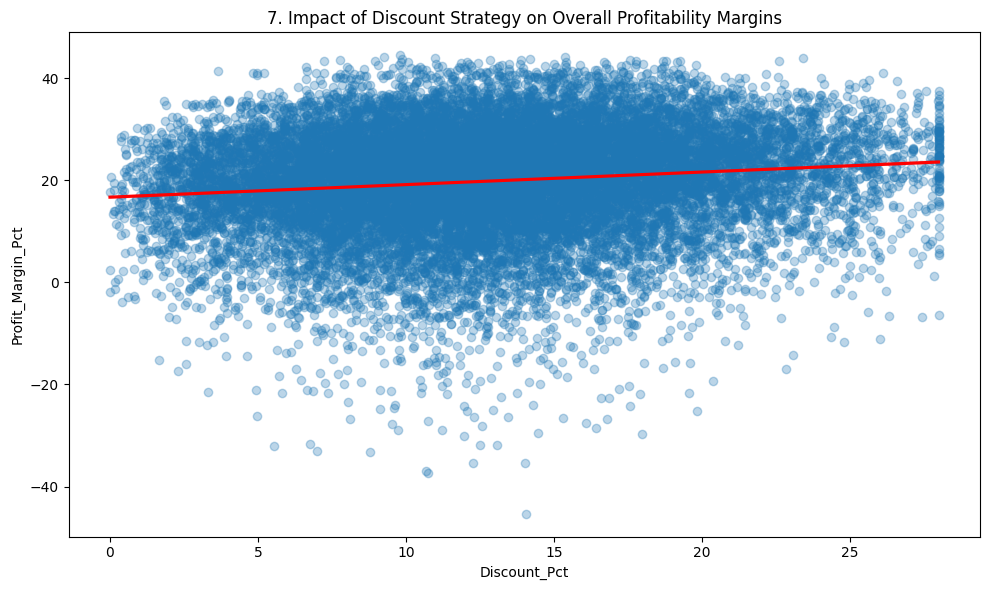

In [19]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Discount_Pct', y='Profit_Margin_Pct', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'{plot_no}. Impact of Discount Strategy on Overall Profitability Margins')
show_fig()
plot_no += 1

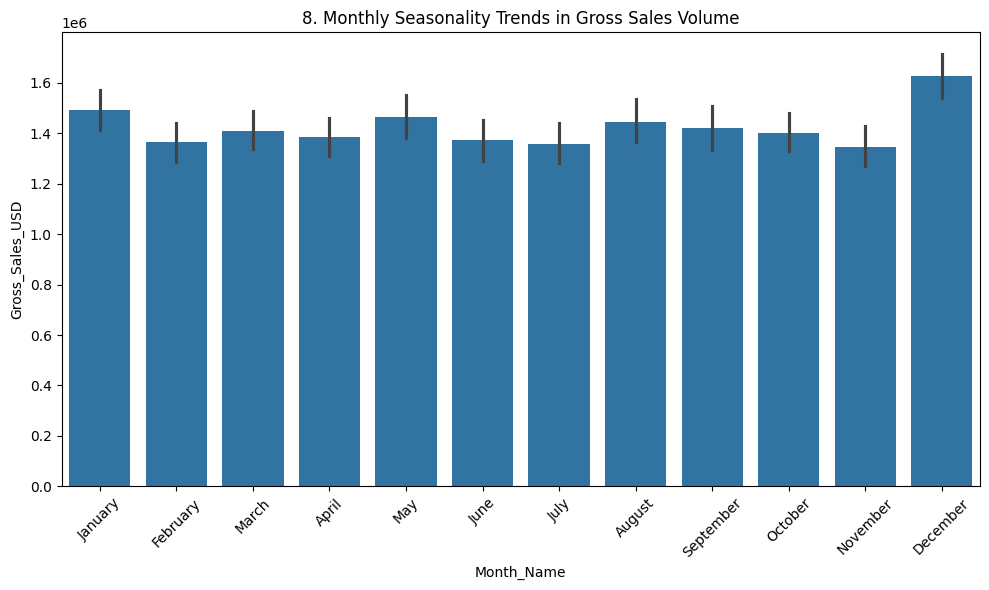

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Month_Name', y='Gross_Sales_USD', estimator='sum', order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Monthly Seasonality Trends in Gross Sales Volume')
show_fig()
plot_no += 1

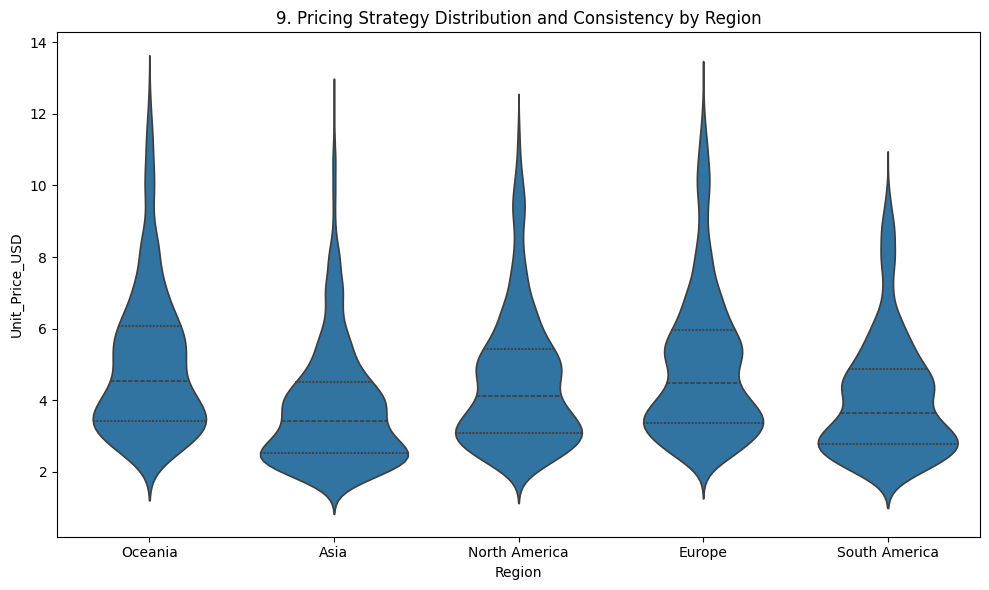

In [21]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Region', y='Unit_Price_USD', inner='quartile')
plt.title(f'{plot_no}. Pricing Strategy Distribution and Consistency by Region')
show_fig()
plot_no += 1

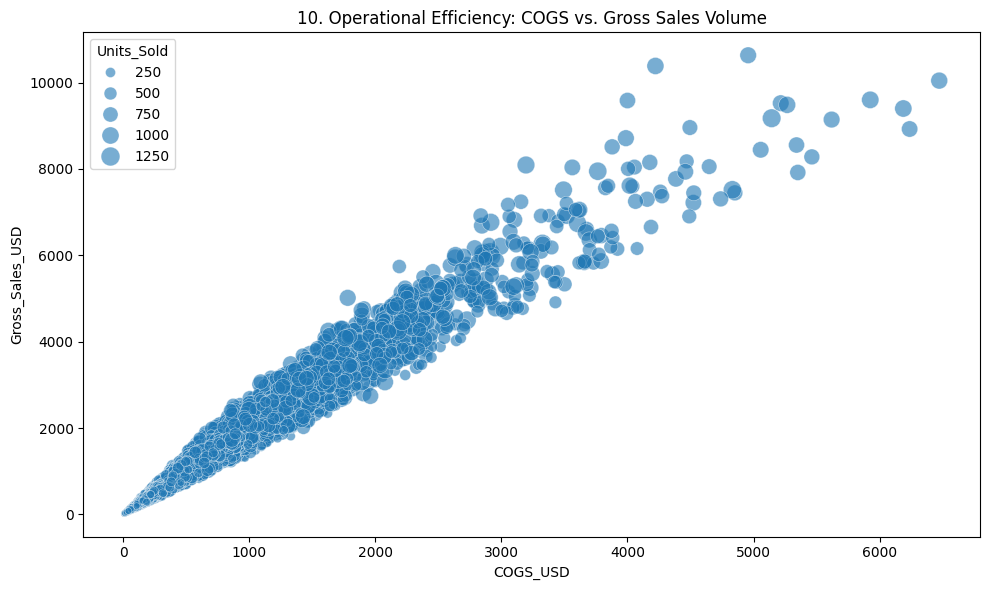

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='COGS_USD', y='Gross_Sales_USD', size='Units_Sold', sizes=(20, 200), alpha=0.6)
plt.title(f'{plot_no}. Operational Efficiency: COGS vs. Gross Sales Volume')
show_fig()
plot_no += 1

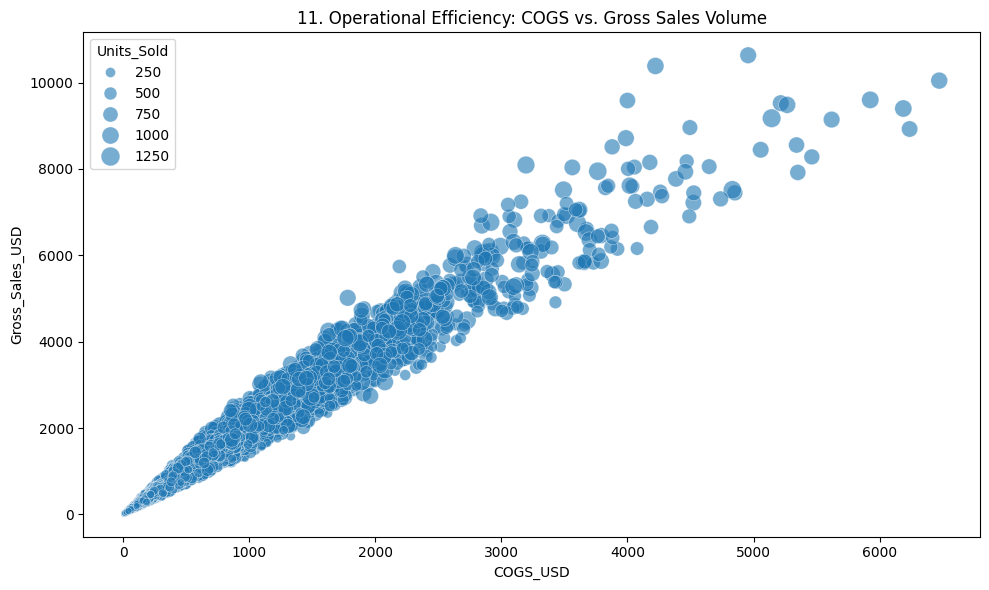

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='COGS_USD', y='Gross_Sales_USD', size='Units_Sold', sizes=(20, 200), alpha=0.6)
plt.title(f'{plot_no}. Operational Efficiency: COGS vs. Gross Sales Volume')
show_fig()
plot_no += 1

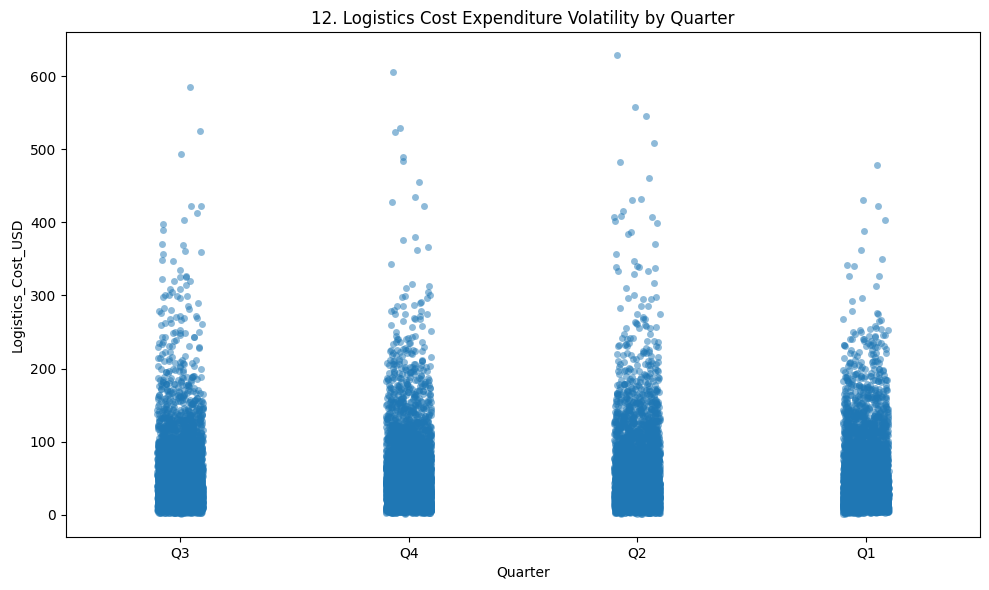

In [24]:
fig = plt.figure(figsize=(10,6))
sns.stripplot(data=df, x='Quarter', y='Logistics_Cost_USD', jitter=True, alpha=0.5)
plt.title(f'{plot_no}. Logistics Cost Expenditure Volatility by Quarter')
show_fig()
plot_no += 1

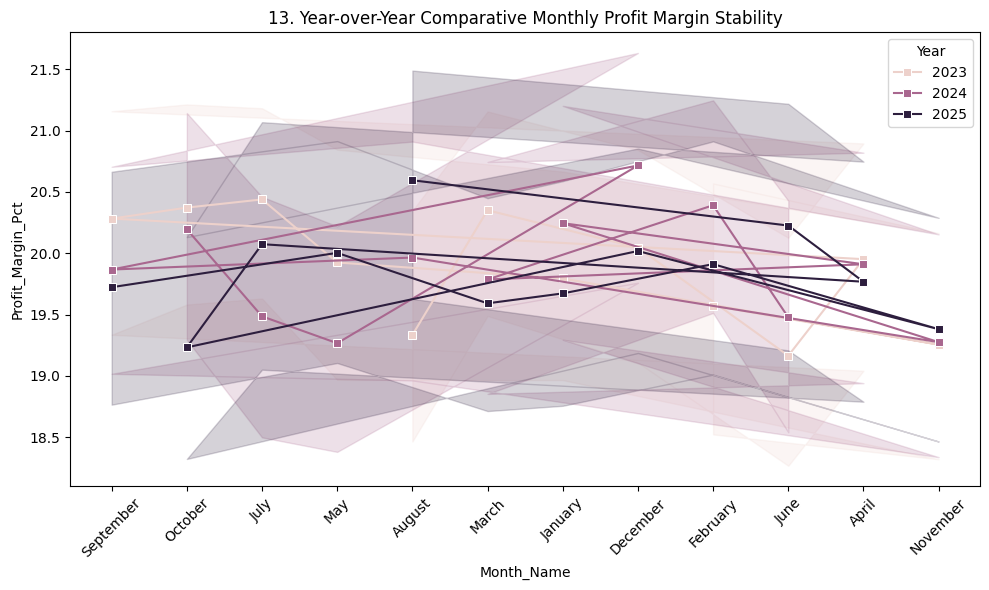

In [25]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Month_Name', y='Profit_Margin_Pct', hue='Year', marker='s', sort=False)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Year-over-Year Comparative Monthly Profit Margin Stability')
show_fig()
plot_no += 1

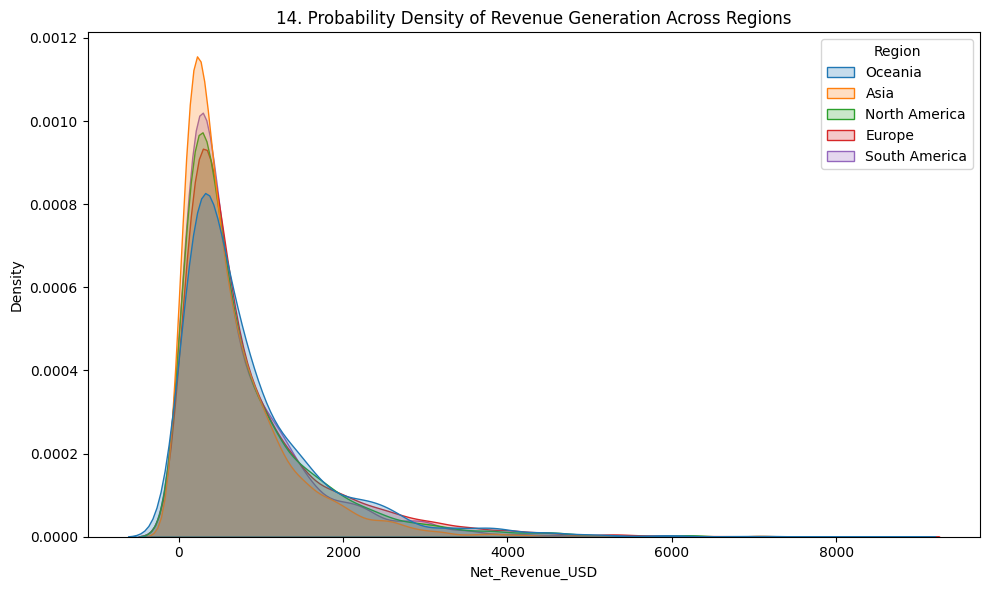

In [26]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Net_Revenue_USD', hue='Region', fill=True, common_norm=False)
plt.title(f'{plot_no}. Probability Density of Revenue Generation Across Regions')
show_fig()
plot_no += 1

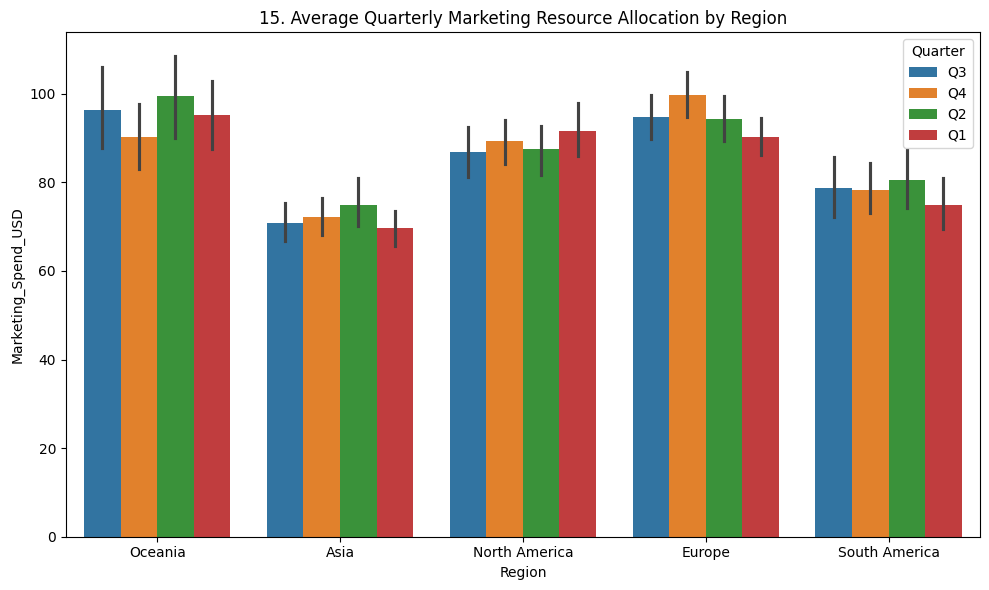

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Region', y='Marketing_Spend_USD', hue='Quarter', estimator='mean')
plt.title(f'{plot_no}. Average Quarterly Marketing Resource Allocation by Region')
show_fig()
plot_no += 1

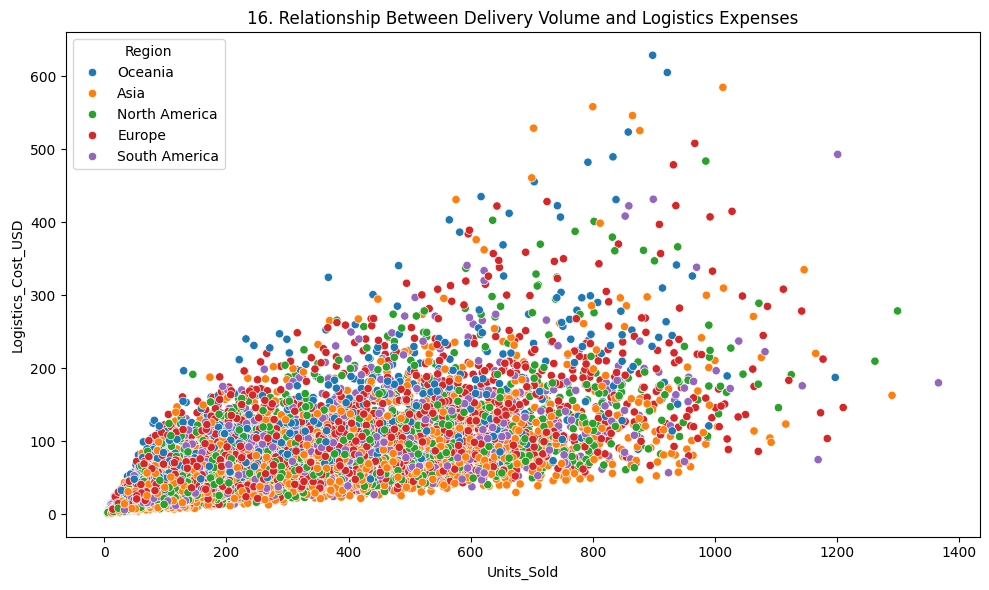

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Units_Sold', y='Logistics_Cost_USD', hue='Region')
plt.title(f'{plot_no}. Relationship Between Delivery Volume and Logistics Expenses')
show_fig()
plot_no += 1

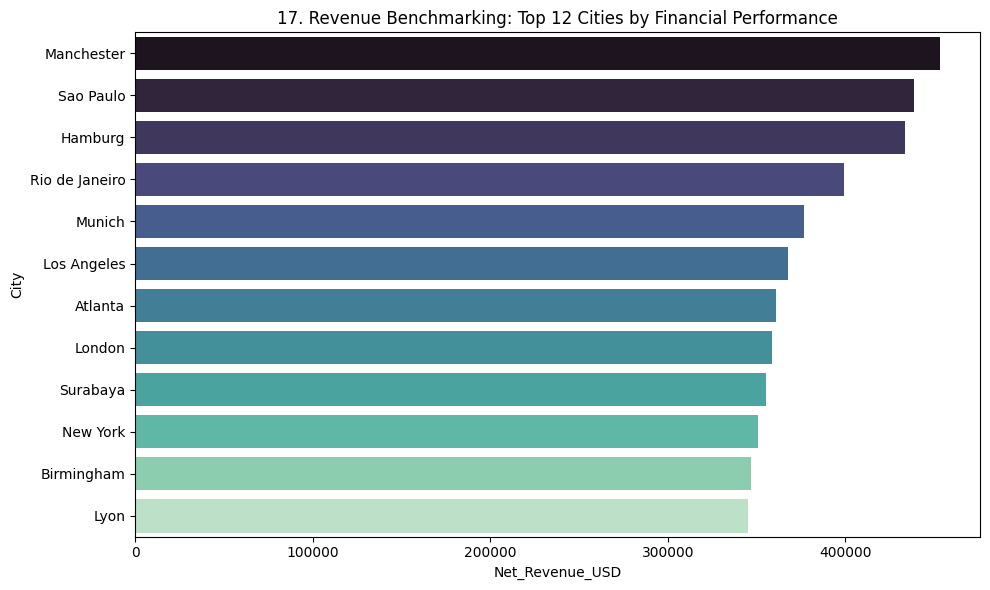

In [29]:
fig = plt.figure(figsize=(10,6))
city_perf = df.groupby('City')['Net_Revenue_USD'].sum().nlargest(12).reset_index()
sns.barplot(data=city_perf, x='Net_Revenue_USD', y='City', palette='mako')
plt.title(f'{plot_no}. Revenue Benchmarking: Top 12 Cities by Financial Performance')
show_fig()
plot_no += 1

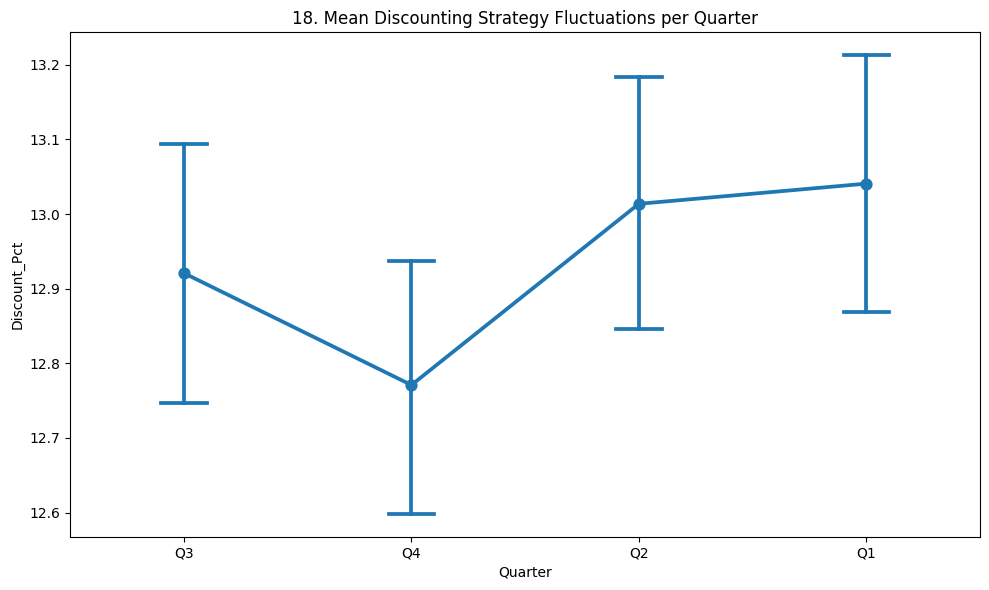

In [30]:
fig = plt.figure(figsize=(10,6))
sns.pointplot(data=df, x='Quarter', y='Discount_Pct', capsize=.2)
plt.title(f'{plot_no}. Mean Discounting Strategy Fluctuations per Quarter')
show_fig()
plot_no += 1

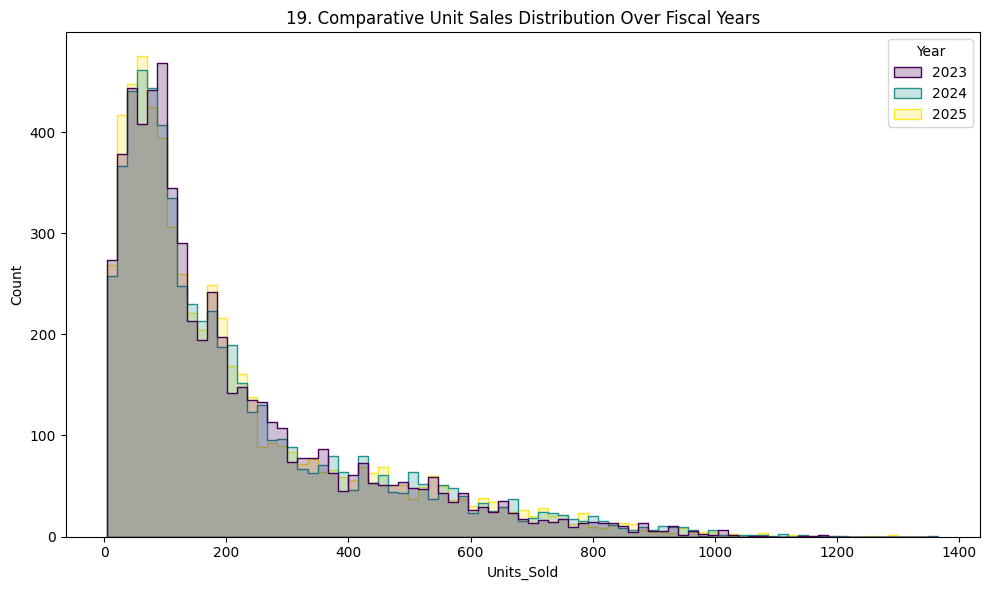

In [31]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Units_Sold', hue='Year', element='step', palette='viridis')
plt.title(f'{plot_no}. Comparative Unit Sales Distribution Over Fiscal Years')
show_fig()
plot_no += 1

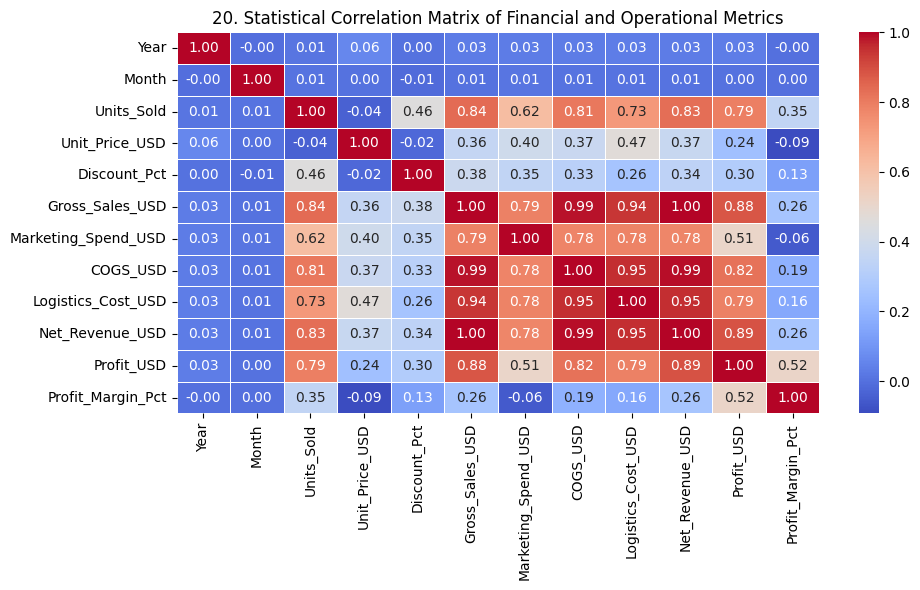

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Statistical Correlation Matrix of Financial and Operational Metrics')
show_fig()
plot_no += 1

# Model Training

## Select numeric features and target variable

In [33]:
features = ['Units_Sold', 'Unit_Price_USD', 'Discount_Pct', 'Marketing_Spend_USD', 'COGS_USD', 'Logistics_Cost_USD']
X = df[features]
y = df['Net_Revenue_USD']

## Split data into training and testing sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale features to ensure uniform contribution to the model

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Initialize and train the Gradient Boosting Regressor

In [36]:
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train_scaled, y_train)

GradientBoostingRegressor(random_state=42)

## Predict on the test set

In [37]:
y_pred = model.predict(X_test_scaled)

## Calculate and print the R-squared accuracy score

In [38]:
accuracy = r2_score(y_test, y_pred)
print(f"Model R-squared Accuracy Score: {accuracy:.4f}")

Model R-squared Accuracy Score: 0.9887


## Plot Actual vs Predicted values for performance visualization

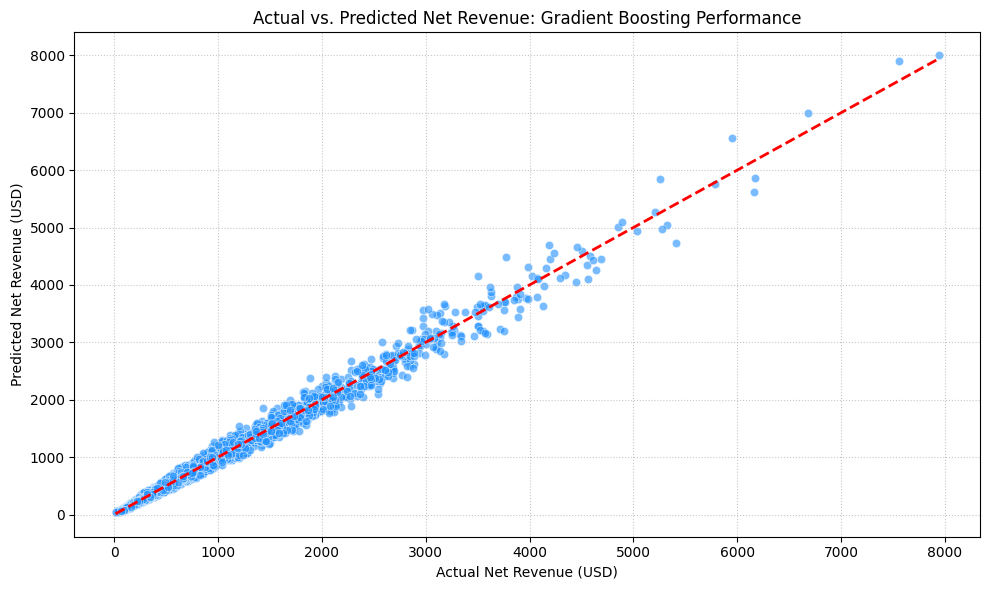

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual Net Revenue (USD)')
plt.ylabel('Predicted Net Revenue (USD)')
plt.title('Actual vs. Predicted Net Revenue: Gradient Boosting Performance')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()